## Learning Lyapunov function for Inverted Pendulum

In [97]:
# -*- coding: utf-8 -*-
from dreal import *
from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

## Neural network model
Building NN with random parameters for Lyapunov function and initializing parameters of NN controller to LQR solution

LQR solution is obtained by minimizing the cost function J = ∫(xᵀQx + uᵀRu)dt, where Q is 2×2 identity matrix and R is 1×1 identity matrix

In [98]:
class Net(torch.nn.Module):
    
    def __init__(self,n_input,n_hidden,n_output,lqr):
        super(Net, self).__init__()
        torch.manual_seed(2)
        self.layer1 = torch.nn.Linear(n_input, n_hidden)
        self.activation1 = torch.nn.Tanh()
        self.layer2 = torch.nn.Linear(n_hidden,n_output)
        self.activation2 = torch.nn.Tanh()
        self.control = torch.nn.Linear(n_input,1,bias=False)
        self.control.weight = torch.nn.Parameter(lqr)

    def forward(self,x):
        # sigmoid = torch.nn.Tanh()
        h_1 = self.activation1(self.layer1(x))
        out = self.activation2(self.layer2(h_1))
        u = self.control(x)
        return out,u

## Dynamical system

In [99]:
A = [[-1, 0], [0, -1]]
B = [[1], [1]]

def f_value(x,u):
    #Dynamics
    y = []
    G = 9.81  # gravity
    L = 0.5   # length of the pole 
    m = 0.15  # ball mass
    b = 0.2   # friction
    
    for r in range(0,len(x)): 
        f = [ x[r][1], 
              (m*G*L*np.sin(x[r][0])- b*x[r][1]) / (m*L**2)]
        y.append(f) 
    y = torch.tensor(y)
    y[:,1] = y[:,1] + (u[:,0]/(m*L**2))

    # y = torch.zeros(x.shape, device=x.device)
    
    # A_ = torch.tensor(A, dtype=torch.float32)
    # B_ = torch.tensor(B, dtype=torch.float32).squeeze()
    
    # for r in range(0,len(x)): 
    #     y[r] = A_ @ x[r] + B_*u[r]

    return y

## Options

In [ ]:
'''
For learning 
'''
N = 500             # sample size
D_in = 2            # input dimension
H1 = 6              # hidden dimension
D_out = 1           # output dimension
torch.manual_seed(10)  
x = torch.Tensor(N, D_in).uniform_(-6, 6).to(torch.float32)
x_0 = torch.zeros([1, 2], dtype=torch.float32)

'''
For verifying 
'''
x1 = Variable("x1")
x2 = Variable("x2")
vars_ = [x1,x2]
G = 9.81 
l = 0.5  
m = 0.15
b = 0.2
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-2
epsilon = 0
# Checking candidate V within a ball around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub)
ball_lb = 0.5
ball_ub = 4

## Learning and Falsification

In [101]:
out_iters = 0
valid = False
while out_iters < 2 and not valid: 
    start = timeit.default_timer()
    lqr = torch.tensor([[-23.58639732,  -5.31421063]], dtype=torch.float32)    # lqr solution
    # lqr = torch.tensor([[0.3660, 0.3660]], dtype=torch.float32)    # lqr solution
    
    model = Net(D_in,H1, D_out,lqr)
    L = []
    i = 0 
    t = 0
    max_iters = 2000
    learning_rate = 0.01
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01, alpha=0.99, eps=1e-8, weight_decay=1e-4)


    while i < max_iters and not valid: 
        V_candidate, u = model(x)
        X0,u0 = model(x_0)
        f = f_value(x,u)
        Circle_Tuning = Tune(x)
        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
        L_V = torch.diagonal(torch.mm(torch.mm(torch.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(torch.tanh(torch.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)

        # With tuning term 
        # Lyapunov_risk = (F.relu(-V_candidate)+ 1.5*F.relu(L_V+0.5)).mean()\
                    # +2.2*((Circle_Tuning-6*V_candidate).pow(2)).mean()+(X0).pow(2) 
        # Without tuning term
        Lyapunov_risk = (F.relu(-V_candidate)+ 2.5*F.relu(L_V+0.5)).mean()+ (X0).pow(2)

        # Lyapunov_risk = (F.relu(-V_candidate)+ F.relu(L_V+0.5)).mean()+ (X0).pow(2)
        
        
        print(i, "Lyapunov Risk=",Lyapunov_risk.item()) 
        L.append(Lyapunov_risk.item())
        optimizer.zero_grad()
        Lyapunov_risk.backward()
        optimizer.step() 

        w1 = model.layer1.weight.data.numpy()
        w2 = model.layer2.weight.data.numpy()
        b1 = model.layer1.bias.data.numpy()
        b2 = model.layer2.bias.data.numpy()
        q = model.control.weight.data.numpy()

        # Falsification
        if i % 10 == 0:
            u_NN = (q.item(0)*x1 + q.item(1)*x2) 
            f = [ x2,
                 (m*G*l*sin(x1) + u_NN - b*x2) /(m*l**2)]
            
            # f = np.dot(A-B@q, vars_)

            # Candidate V
            z1 = np.dot(vars_,w1.T)+b1

            a1 = []
            for j in range(0,len(z1)):
                a1.append(tanh(z1[j]))
            z2 = np.dot(a1,w2.T)+b2
            V_learn = tanh(z2.item(0))

            print('===========Verifying==========')        
            start_ = timeit.default_timer() 
            result= CheckLyapunov(vars_, f, V_learn, ball_lb, ball_ub, config,epsilon)
            
            stop_ = timeit.default_timer() 

            if (result): 
                print("Not a Lyapunov function. Found counterexample: ")
                print(result)
                # print("Result Multi Lyapunov Check ", result2)
                x = AddCounterexamples(x,result,10).to(torch.float32)
            else:  
                valid = True
                print("Satisfy conditions!!")
                print(V_learn, " is a Lyapunov function.")

                switch_condition = x1 <= 0
                result2 = CheckLyapunovMultiple(vars_, f, f, switch_condition, V_learn, V_learn, ball_lb, ball_ub, config, epsilon)
                print("Result Multi Lyapunov Check ", result2)
            t += (stop_ - start_)
            print('==============================') 
        i += 1

    stop = timeit.default_timer()


    np.savetxt("w1.txt", model.layer1.weight.data, fmt="%s")
    np.savetxt("w2.txt", model.layer2.weight.data, fmt="%s")
    np.savetxt("b1.txt", model.layer1.bias.data, fmt="%s")
    np.savetxt("b2.txt", model.layer2.bias.data, fmt="%s")
    np.savetxt("q.txt", model.control.weight.data, fmt="%s")

    print('\n')
    print("Total time: ", stop - start)
    print("Verified time: ", t)
    
    out_iters+=1

/tmp/ipykernel_96874/546710405.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  (m*G*L*np.sin(x[r][0])- b*x[r][1]) / (m*L**2)]


0 Lyapunov Risk= 34.293190002441406
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-5.8829002417694864, -5.877444248206114]
x2 : [0.64951905283832911, 0.65459342043862856]
1 Lyapunov Risk= 19.765233993530273
2 Lyapunov Risk= 14.876258850097656
3 Lyapunov Risk= 11.394678115844727
4 Lyapunov Risk= 7.350123405456543
5 Lyapunov Risk= 4.211788654327393
6 Lyapunov Risk= 2.2161829471588135
7 Lyapunov Risk= 1.1184083223342896
8 Lyapunov Risk= 0.5849369168281555
9 Lyapunov Risk= 0.3273688554763794
10 Lyapunov Risk= 0.4665718376636505
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-1.4229706896938934, -1.4129706896938936]
x2 : [5.7908257049890857, 5.8008257049890855]
11 Lyapunov Risk= 1.0476001501083374
12 Lyapunov Risk= 1.2607300281524658
13 Lyapunov Risk= 1.0890100002288818
14 Lyapunov Risk= 0.8192670345306396
15 Lyapunov Risk= 0.5440177917480469
16 Lyapunov Risk= 0.44699692726135254
17 Lyapunov Risk= 0.398690015077590

In [134]:
# evaluate counter example

ce = np.array([result[0].mid(), result[1].mid()])
# ce = np.array([result[0].ub(), result[1].ub()])
# ce = np.array([result[0].lb(), result[1].lb()])

f = [ ce[1],
      (m*G*l*np.sin(ce[0]) + np.dot(q, ce).squeeze() - b*ce[1]) /(m*l**2)]

# Lyapunov function
lf = np.tanh(np.dot(np.tanh(np.dot(ce, w1.T) + b1), w2.T) + b2)

# Lie Derivative
ld = np.dot( np.matmul( np.matmul(dtanh(lf), w2) * dtanh(np.tanh(np.matmul(ce,w1.T)+b1)),w1 ),f )

# Origin value 
v0 = np.tanh(np.dot(np.tanh(np.dot(np.zeros(2), w1.T) + b1), w2.T) + b2)

print("Constraints: V(.) > 0, dV(.) < 0, V(0) = 0")
print(f'Counter Example: V(x) = {lf.item():.2f}, dV(x) = {ld.item():.2f}, v0 = {v0.item():.2f}')

Constraints: V(.) > 0, dV(.) < 0, V(0) = 0
Counter Example: V(x) = 0.00, dV(x) = 0.01, v0 = 0.01


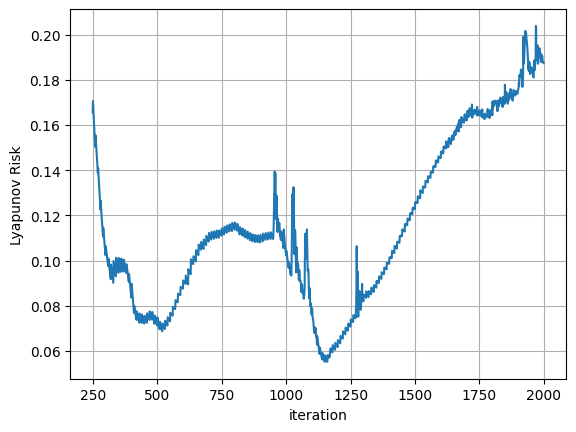

In [135]:
start = 250
plt.figure()
plt.plot(range(start, len(L)),L[start:])
plt.grid()
plt.xlabel('iteration')
plt.ylabel('Lyapunov Risk')
plt.show()

### Checking result with smaller epsilon ( Lie derivative of V <= epsilon )

In [ ]:
epsilon = -0.00001
start_ = timeit.default_timer() 
result = CheckLyapunov(vars_, f, V_learn, ball_lb, ball_ub, config, epsilon)
stop_ = timeit.default_timer() 

if (result): 
    print("Not a Lyapunov function. Found counterexample: ")
else:  
    print("Satisfy conditions with epsilon= ",epsilon)
    print(V_learn, " is a Lyapunov function.")
t += (stop_ - start_)

TypeError: unsupported operand type(s) for *: 'Tensor' and 'dreal._dreal_py.Expression'

### More details on Lyapunov risk
Generally, we start training with Lyapunov risk without the tuning term.      
For example, (1* F.relu(-V_candidate)+ 1.5* F.relu(L_V+0.5)).mean()+ 1.2*(X0).pow(2)    
The weight of each term (1, 1.5, 1.2) can be tuned for balancing each Lyapunov condition.     
Furthermore, using F.relu(L_V+0.5) allows the learning procedure to seek a candidate Lyapunov function with more negative Lie derivative.   
Here 0.5 is also a tunable parameter based on your goal.    
In this example, we use Lyapunov risk with tuning term for achieving large ROA     